# Лабораторная работа №1.  Дискретные преобразования сигналов.

Курс: Лаборатория цифровой обработки сигналов (ФРКТ, ФАКТ), осенний семестр.

LMS: https://lms.mipt.ru/course/view.php?id=4561&type=lab


* Перед выполненнием задач нужно ознакомиться с руководством по использованию цифрового осциллографа PV6501 в курсах «Радиофизическая лаборатория» и «Лаборатория цифровой обработки сигналов», размещенным на LMS. 

* В ряде задач в этой работе варианты определяются первой буквой Вашей фамилии. 
* В имени этого файла заменить familyname на Ваши фамилию и имя, либо только фамилию.  
* Перед сдачей необходимо загрузить данный отчет в LMS ответом на задание. 
* Во всех задачах в данной работе не используется пиковый детектор в осциллографе. 


Модуль 1. Дискретизация и квантование.
* Задача 1.1. Сигнал с аналогового датчика.

Модуль 2. Свойства ДВПФ и ДПФ.
* Задача 2.1. Симметрия ДВПФ и ДПФ.
* Задача 2.2. Дополнение нулевыми отсчетами. 
* Задача 2.3. Вычислительная эффективность БПФ.
* Задача 2.4. Периодические последовательности. 

Модуль 3. Частотная ось ДПФ.
* Задача 3.1. Спектр отрезка синусоиды. 
* Задача 3.2. Анализ звукового файла.


In [1]:
# Импорт библиотек и функций
import numpy as np                # импорт бибилиотеки numpy
import matplotlib.pyplot as plt   # импорт модуля matplotlib.pyplot
import scipy.io.wavfile # импорт модуля scipy.io.wavfile
def osc_read_txt(file, const_level=0):
    f = open(file)
    str1 = f.read().split('\n')
    f.close()
    dt, unit = str1[1].replace(',', '.').split(' ')[3:5]
    dt = float(dt)
    if unit=='uS':
        dt*=1e-6
    elif unit=='nS':
        dt*=1e-9
    elif unit=='mS':
        dt*=1e-3
    fs = int(1.0 / dt)
    dv, unit = str1[2].replace(',', '.').split(' ')[3:5]
    dv=float(dv)
    if unit=='mV':
        dv*=1e-3

    zero_level= int(str1[3].split(' ')[3])
    str_num = len(str1)
    signal_lev = np.empty(shape=(str_num-8), dtype=float)
    for k, u in enumerate(range(7, str_num-1, 1)):
        data = str1[u].split()
        signal_lev[k]=(int(data[1])-zero_level)*dv-const_level
    return fs, signal_lev

In [2]:
# Для использования backend matplotlib inline/widget/notebook, раскомментируйте соответствующую строку ниже.
# Установка widget: pip install --upgrade jupyterlab ipympl
# %matplotlib inline
# %matplotlib notebook
%matplotlib widget

# Модуль 1. Дискретизация и квантование. 


## Задача 1.1. Сигнал с аналогового датчика.

Получите с помощью цифрового осциллографа сигнал с аналогового датчика на выбор (например, джойстик, датчик Холла, датчик уровня воды либо сигнал с генератора). Общие настройки управляющей программы осциллографа следующие.

* Синхронизация: «выкл.» или «авто», без внешнего сигнала. 
* Время/дел. в диапазоне ^1S - ^0.1S для датчиков. 
* Открытый вход. 
* Число выборок 8000.
* Пробник 1:1.

```uS``` в управляющей программе осцилографа интерпретируются как микросекунды (мкс, $\mu S$).

Постройте график сигнала, выделяя отдельные дискретные отсчеты точками и соединяя их отрезками прямых (```plt.plot(k/fs, x, '.-')```). Ответьте на следующие вопросы.





1. Какая частота дискретизации у сигнала и как она согласуется с интервалом времени между соседними отсчетами (с шагом дискретизации)?

2. Чему равна длительность записи в секундах? Оцените длительность записи, используя размер массива и данные о шаге дискретизации и сравните с графиком.

3. Какой шаг квантования сигнала? Оцените его по графику и сравните со значением в текстовом файле. 

4. Что отражают разные значения разности потенциалов на выходе датчика? Сопоставьте значения разности потенциалов с измеряемой средой. 

5. Почему для данного эксперимента требуется использовать измерения с открытым входом осциллографа? 

6. В чем отличие между аналоговым сигналом на выходе датчика и цифровым сигналом после АЦП осциллографа? 


In [3]:
file_name = "Data/vian/level_sensor.txt" #"joystick1.txt"

In [4]:
with open(file_name, "r") as f:
    content = f.read()
    print(content[:199]) # Печать первых символов в файле

Oscilloscope data. 
Time step = 625,0 uS
Voltage step = 62,50 mV
Zero level = 127

N 	Smpl.	Trig

0	131	0
1	131	0
2	131	0
3	131	0
4	131	0
5	131	0
6	131	0
7	131	0
8	131	0
9	131	0
10	131	0
11	131	0
12	


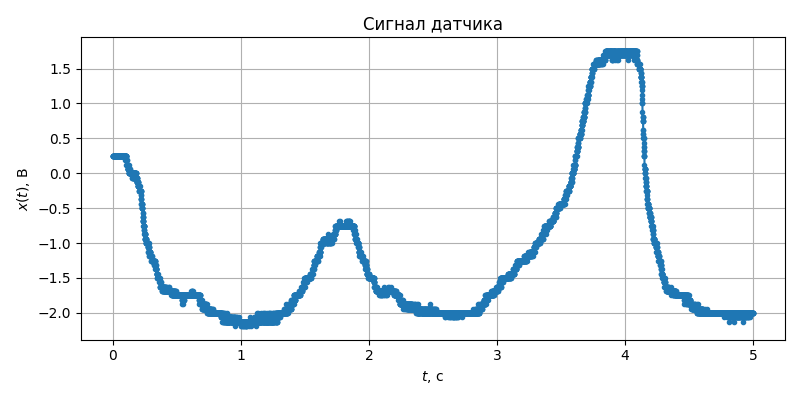


1. Какая частота дискретизации у сигнала и как она согласуется с интервалом времени между соседними отсчетами (с шагом дискретизации)?
fs=1600=1/dt
2. Чему равна длительность записи в секундах? Оцените длительность записи, используя размер массива и данные о шаге дискретизации и сравните с графиком.
T=len(x)*1/fs=5.0
3. Какой шаг квантования сигнала? Оцените его по графику и сравните со значением в текстовом файле.
По графику 0.0625, в файле 62,50 mV
4. Что отражают разные значения разности потенциалов на выходе датчика? Сопоставьте значения разности потенциалов с измеряемой средой.
чем ниже значение тем глубже в воде датчик
5. Почему для данного эксперимента требуется использовать измерения с открытым входом осциллографа?
значения могут быть постоянными, не требуется их отсечки
6. В чем отличие между аналоговым сигналом на выходе датчика и цифровым сигналом после АЦП осциллографа?
он квантован



In [5]:
fs, x = osc_read_txt(file=file_name)
# absc = np.arange(0, 100, dtype=float)
# fs, x = 1e-6, absc + 10*np.sin(absc)
plt.close()
plt.figure(figsize=[8, 4])
plt.title("Сигнал датчика")
k = np.arange(len(x))
plt.plot(k/fs, x, '.-')
plt.grid()
plt.xlabel("$t$, c")
plt.ylabel("$x(t)$, В")
plt.tight_layout()
plt.show()


print(f"""
1. Какая частота дискретизации у сигнала и как она согласуется с интервалом времени между соседними отсчетами (с шагом дискретизации)?
{fs=}=1/dt
2. Чему равна длительность записи в секундах? Оцените длительность записи, используя размер массива и данные о шаге дискретизации и сравните с графиком.
T={len(x)*1/fs=}
3. Какой шаг квантования сигнала? Оцените его по графику и сравните со значением в текстовом файле.
По графику {1.0625-1}, в файле 62,50 mV
4. Что отражают разные значения разности потенциалов на выходе датчика? Сопоставьте значения разности потенциалов с измеряемой средой.
чем ниже значение тем глубже в воде датчик
5. Почему для данного эксперимента требуется использовать измерения с открытым входом осциллографа?
значения могут быть постоянными, не требуется их отсечки
6. В чем отличие между аналоговым сигналом на выходе датчика и цифровым сигналом после АЦП осциллографа?
он квантован
""")

# Модуль 2. Свойства ДВПФ и ДПФ.

## Задача 2.1. Симметрия ДВПФ и ДПФ.
Получите с помощью цифрового осциллографа и встроенного в него генератора одну из реализаций шума с равномерно распределённой в диапазоне от 0 до 10 МГц спектральной плотностью мощности (Кнопка «Noise» при отключенных "АМ/ЧМ", "Импульсы" и "ГКЧ"). Использовать режим **закрытого входа** осциллографа. Для анализа на Python возьмите первые 32 отсчета шума. 

Постройте на одном периоде с помощью компьютерного моделирования графики следующих функций:
* модуль ДВПФ $|X(\nu)|$ и ДПФ $|X[n]|$, 
* фазовую часть ДВПФ $\varphi(\nu)=\angle X(\nu)$ и ДПФ $\angle X[n]$,
* действительную часть ДВПФ $\text{Re } X(\nu)$ и коэффициентов ДПФ $\text{Re } X[n]$,
* мнимую  часть ДВПФ $\text{Im } X(\nu)$ и коэффициентов ДПФ $\text{Im } X[n]$.

Определите, являются ли они симметричными либо антисимметричными относительно нулевой частоты. Почему спектр реализации данного шума, как правило, не является константой?

In [6]:
"0.1uS sampling"

'0.1uS sampling'

In [7]:
1/1e7*1e9  # dt in nsec

100.0

In [8]:
file_name = "Data/vian/noise.txt"
# Считывание сигнала
fs, x = osc_read_txt(file=file_name)


# # generate dummy random sampling
# num_samples = 100
# white_noise = np.random.rand(num_samples) - 0.5
# spectrum = np.fft.fft(white_noise)
# x = spectrum

#x=x-np.mean(x)
x=x[0:32]

# Вычисление ДПФ и ДВПФ
dtft_points=2048
X_dft = np.fft.fftshift(np.fft.fft(x))
f_dft = np.fft.fftshift(np.fft.fftfreq(X_dft.shape[0], d=1.0/fs))
X_dtft = np.fft.fftshift(np.fft.fft(x, dtft_points))
f_dtft = np.fft.fftshift(np.fft.fftfreq(X_dtft.shape[0], d=1.0/fs))


In [9]:
plt.plot(x)

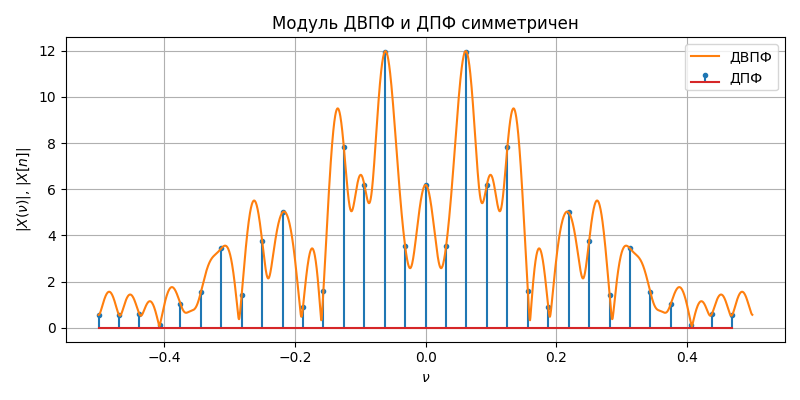

In [10]:
plt.close()
# Пример с построением графиков для модуля ДВПФ и ДПФ.
plt.figure(figsize=[8, 4])
k = np.arange(len(x))
plt.stem(f_dft/fs, abs(X_dft), 'C0', markerfmt=".", label="ДПФ")
plt.plot(f_dtft/fs, abs(X_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ и ДПФ симметричен")
plt.xlabel("$\\nu$")
plt.ylabel("$|X(\\nu)|$, $|X[n]|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()

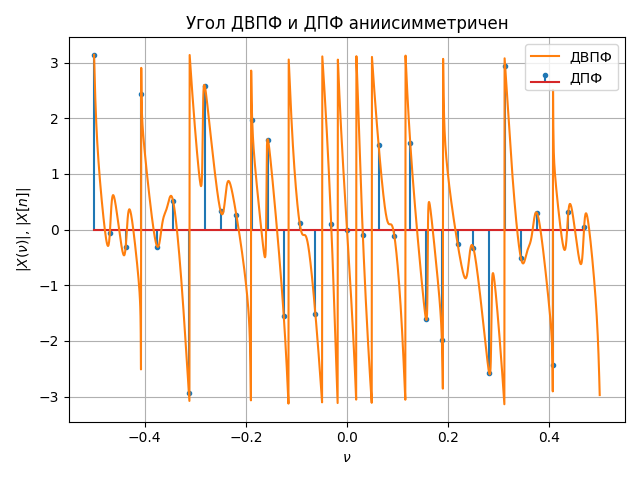

In [11]:
plt.close()
plt.stem(f_dft/fs, np.angle(X_dft), 'C0', markerfmt=".", label="ДПФ")
plt.plot(f_dtft/fs, np.angle(X_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Угол ДВПФ и ДПФ аниисимметричен")
plt.xlabel("$\\nu$")
plt.ylabel("$|X(\\nu)|$, $|X[n]|$")
plt.legend()
plt.tight_layout()
plt.show()

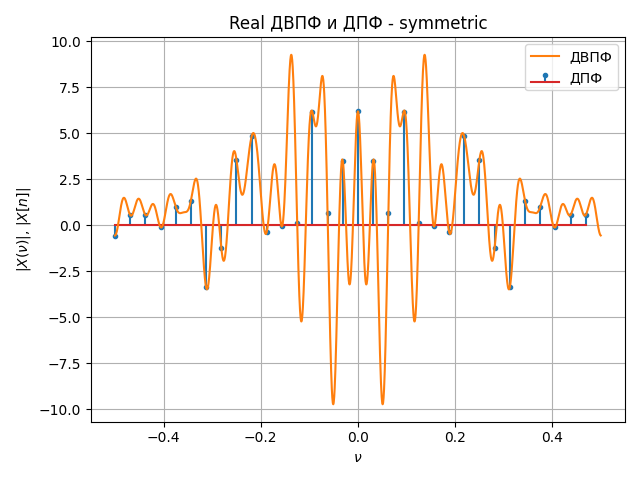

In [12]:
plt.close()
plt.stem(f_dft/fs, np.real(X_dft), 'C0', markerfmt=".", label="ДПФ")
plt.plot(f_dtft/fs, np.real(X_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Real ДВПФ и ДПФ - symmetric")
plt.xlabel("$\\nu$")
plt.ylabel("$|X(\\nu)|$, $|X[n]|$")
plt.legend()
plt.tight_layout()
plt.show()

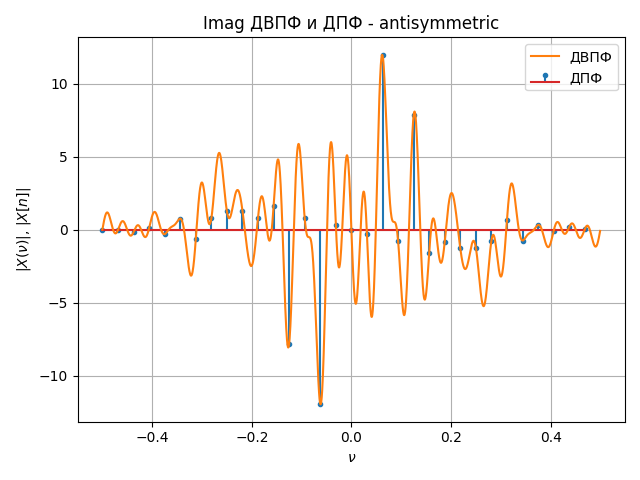

In [13]:
plt.close()
plt.stem(f_dft/fs, np.imag(X_dft), 'C0', markerfmt=".", label="ДПФ")
plt.plot(f_dtft/fs, np.imag(X_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Imag ДВПФ и ДПФ - antisymmetric")
plt.xlabel("$\\nu$")
plt.ylabel("$|X(\\nu)|$, $|X[n]|$")
plt.legend()
plt.tight_layout()
plt.show()

## Задача 2.2. Дополнение нулевыми отсчетами.

Дополните выборку из задачи 2.1 (длиной в 32 такта дискретизации) нулевыми отсчетами справа до длины $M>N$. Параметр $M$ подберите таким, чтобы спектр достаточно хорошо визуализировался с помощью отсчетов ДПФ.
1) Повторите построение графика для модуля ДВПФ и ДПФ. 
2) Постройте график сигнала до и после дополнения нулевыми отсчетами. 
3) Определите, чему равно расстояние между каждой парой соседних отсчетов вдоль оси частот в задаче 2.1 и для подобранного Вами $M$ в задаче 2.2. 
4) Повторите построение ДПФ и ДВПФ из п. 1 без предварительного дополнения нулями, указывая второй параметр функции fft: ```np.fft.fft(x, M)```. Сравните результаты.

In [14]:
M=256
y=np.zeros(M)
y[0:len(x)]=x
y

array([ 1.25  ,  0.5   , -0.5   , -1.125 , -0.5   ,  0.125 , -0.5   ,
       -0.5   ,  0.625 ,  0.75  ,  0.    ,  0.625 ,  1.125 ,  1.25  ,
        1.0625,  0.5625, -0.625 , -1.125 , -1.    , -1.    , -0.5   ,
        0.1875,  0.    ,  0.6875,  0.625 , -0.5625, -0.5625,  0.75  ,
        1.1875,  1.1875,  1.125 ,  1.0625,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
        0.    ,  0. 

> 3) Определите, чему равно расстояние между каждой парой соседних отсчетов вдоль оси частот в задаче 2.1 и для подобранного Вами $M$ в задаче 2.2. 

df = fs/len(x)

In [15]:
print(f'2.1: {fs/32}, 2.2: {fs/M}')

2.1: 3125000.0, 2.2: 390625.0


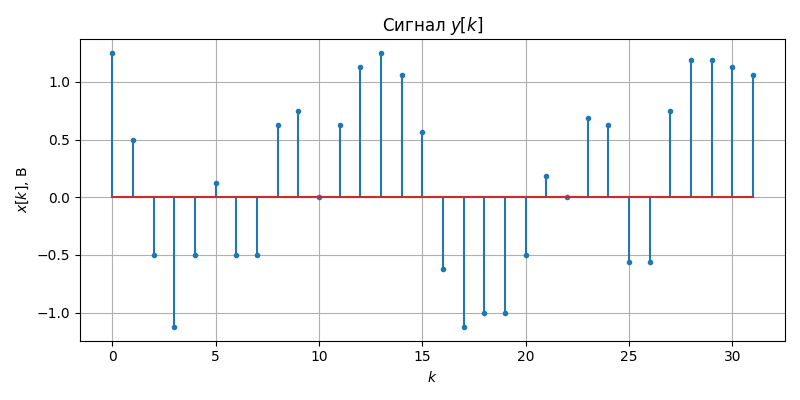

In [16]:
plt.figure(figsize=[8, 4])
plt.title("Сигнал $y[k]$")
k = np.arange(len(x))
plt.stem(k, x, markerfmt='.')
plt.grid()
plt.xlabel("$k$")
plt.ylabel("$x[k]$, В")
plt.tight_layout()
plt.show()

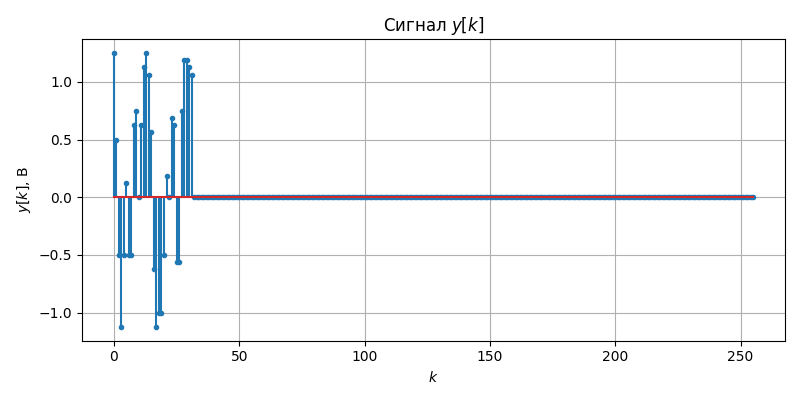

In [17]:
plt.figure(figsize=[8, 4])
plt.title("Сигнал $y[k]$")
k = np.arange(len(y))
plt.stem(k, y, markerfmt='.')
plt.grid()
plt.xlabel("$k$")
plt.ylabel("$y[k]$, В")
plt.tight_layout()
plt.show()

In [18]:
dtft_points=2048
YX_dft = np.fft.fftshift(np.fft.fft(y))
Yf_dft = np.fft.fftshift(np.fft.fftfreq(YX_dft.shape[0], d=1.0/fs))
YX_dtft = np.fft.fftshift(np.fft.fft(y, dtft_points))
Yf_dtft = np.fft.fftshift(np.fft.fftfreq(YX_dtft.shape[0], d=1.0/fs))

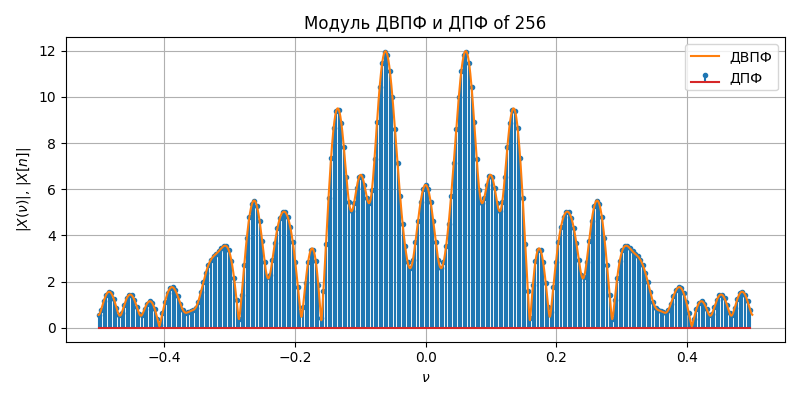

In [19]:
# Пример с построением графиков для модуля ДВПФ и ДПФ.
plt.figure(figsize=[8, 4])
yk = np.arange(len(y))
plt.stem(Yf_dft/fs, abs(YX_dft), 'C0', markerfmt=".", label="ДПФ")
plt.plot(Yf_dtft/fs, abs(YX_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title(f"Модуль ДВПФ и ДПФ of {M}")
plt.xlabel("$\\nu$")
plt.ylabel("$|X(\\nu)|$, $|X[n]|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()

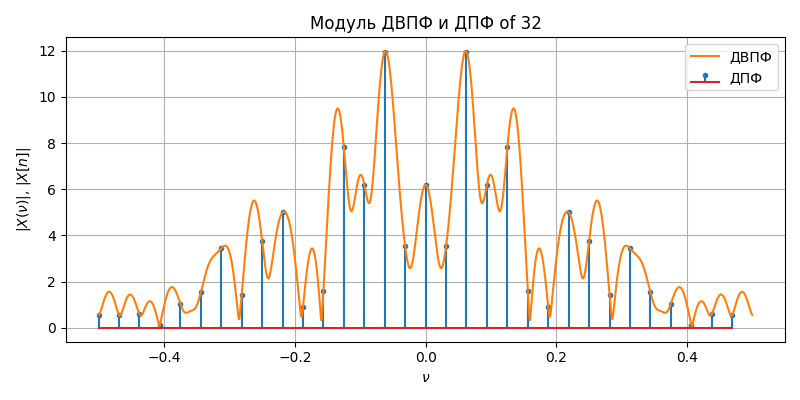

In [20]:
# Пример с построением графиков для модуля ДВПФ и ДПФ.
plt.figure(figsize=[8, 4])
yk = np.arange(len(y))
plt.stem(f_dft/fs, abs(X_dft), 'C0', markerfmt=".", label="ДПФ")
plt.plot(f_dtft/fs, abs(X_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ и ДПФ of 32")
plt.xlabel("$\\nu$")
plt.ylabel("$|X(\\nu)|$, $|X[n]|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()

In [21]:
# specify M as 2nd arg
dtft_points=2048
YX_dft = np.fft.fftshift(np.fft.fft(x, M))
Yf_dft = np.fft.fftshift(np.fft.fftfreq(YX_dft.shape[0], d=1.0/fs))
YX_dtft = np.fft.fftshift(np.fft.fft(x, dtft_points))
Yf_dtft = np.fft.fftshift(np.fft.fftfreq(YX_dtft.shape[0], d=1.0/fs))

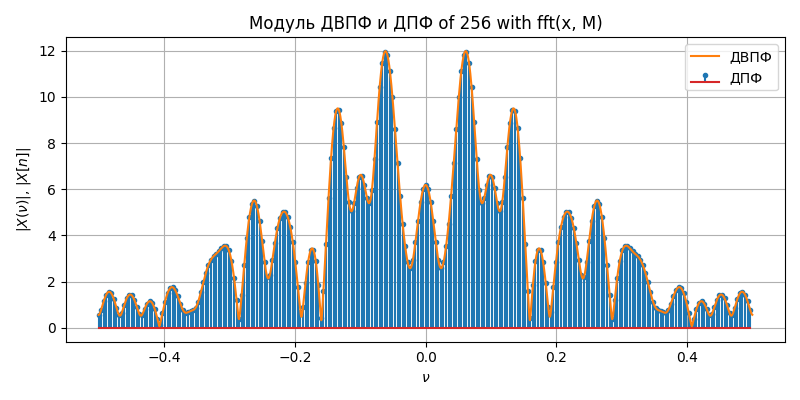

In [22]:
# Пример с построением графиков для модуля ДВПФ и ДПФ.
plt.figure(figsize=[8, 4])
yk = np.arange(len(y))
plt.stem(Yf_dft/fs, abs(YX_dft), 'C0', markerfmt=".", label="ДПФ")
plt.plot(Yf_dtft/fs, abs(YX_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title(f"Модуль ДВПФ и ДПФ of {M} with fft(x, M)")
plt.xlabel("$\\nu$")
plt.ylabel("$|X(\\nu)|$, $|X[n]|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()

## Задача 2.3. Вычислительная эффективность БПФ.

В этой и в некоторых других задачах варианты определяются первой буквой Вашей фамилии.

| Первая буква: | А,Б | В,Г | Д,Е,Ё | Ж,З,И,Й,К | Л,М | Н,О | П,Р | С,Т,У,Ф | Х,Ц,Ч,Ш,Щ,Ы | Э,Ю,Я |
|:---------:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
|   **N**   |   512 |   512 |   256 |   256 |   512 |   512 |   512 |   512 |   512 |   256 |
|   **P**   | 32768 | 32768 | 65536 | 65536 | 32768 | 65536 | 32768 | 65536 | 32768 | 32768 |

Дана $N$-точечная последовательность отсчетов
$$ x[k]= \sin(2\pi kn_0/N)$$  
Посчитать ДВПФ с использованием Python в $P$ точках для этой последовательности, где $n_0$ выбранное вами целое число на отрезке $ 0 < n_0 < N/2 $
* используя формулы ДВПФ напрямую, 
* используя БПФ `fft(x, P)`. 

Сравнить максимальную ошибку и время работы программы в двух случаях. Построить график $|X(\nu)|$.

In [23]:
P = 32768
N = 512
x = np.sin(2*np.pi*np.arange(N)*1/4)

print('fft:')
%timeit np.fft.fft(x, P)

y1 = np.fft.fft(x, P)

def my_fft(x, P):
    Xn2 = np.zeros(P, dtype=complex)
    k = np.arange(len(x))
    for u in range(P):
        Xn2[u]= Xn2[u] + np.dot(np.exp(-1j*k*2*np.pi*u/P), x)
    return Xn2

print('just a loop:')
%timeit my_fft(x, P)

y2 = my_fft(x, P)

print('max relative error:', np.abs(y1-y2).max()/np.abs(y1).max())

fft:
520 µs ± 43.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
just a loop:
844 ms ± 19.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
max relative error: 6.351584371392269e-14


## Задача 2.4. Периодические последовательности.

| Первая буква: | А,Б | В,Г | Д,Е,Ё | Ж,З,И,Й,К | Л,М | Н,О | П,Р | С,Т,У,Ф | Х,Ц,Ч,Ш,Щ,Ы | Э,Ю,Я |
|:---------:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
|   **N**   | 16 | 12 | 14 | 16 | 14 | 12 | 24 | 20 | 18 | 16 |
|   $r_1$   |  3 |  2 |  6 |  7 |  6 |  1 |  7 |  3 |  3 |  2 |
|   $r_2$   |  7 |  4 |  2 |  3 |  4 |  4 |  5 |  7 |  5 |  5 |

Задана периодическая последовательность с периодом $N$
$$x[k]=\sin(2\pi k r_1/N)+\cos(2\pi k r_2/N).$$ 
* Вычислите аналитически ДВПФ
* Вычислите с помощью моделирования $N$—точечное ДПФ этой последовательности $\tilde{X} [n]$ (с нормировкой на число отсчетов). 

* Сравните веса $\delta$-функций в ДВПФ и величины отсчетов ДПФ.

Analytical: $`DTFT(x[k]) = DTFT(sin(..r1)) + DTFT(cos(...r2)) = \sum_{n=-\inf}^{\inf} \left( 1/2j \cdot \delta(\nu - r1/N + n) - 1/2j \cdot \delta(\nu + r1/N + n) + 1/2 \cdot \delta(\nu - r2/N + n) + 1/2 \cdot \delta(\nu - r1/N + n) \right) `$

in abs: $ 1/2 * (delta(\nu \pm 6/14) + delta(\nu \pm 4/14)) = 1/2 * (delta(\nu \pm 0.43) + delta(\nu \pm 0.3)) $

In [24]:
N = 14
r1 = 6
r2 = 4

x = np.arange(N)
x, x.shape

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]), (14,))

In [25]:
plt.close('all')

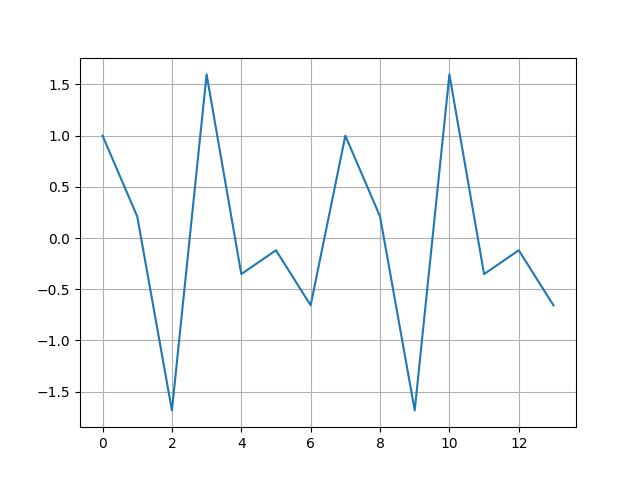

In [26]:
y = np.sin(x * 2 * np.pi * r1 / N) + np.cos(x * 2 * np.pi * r2 / N)
plt.close()
plt.plot(y)
plt.grid()

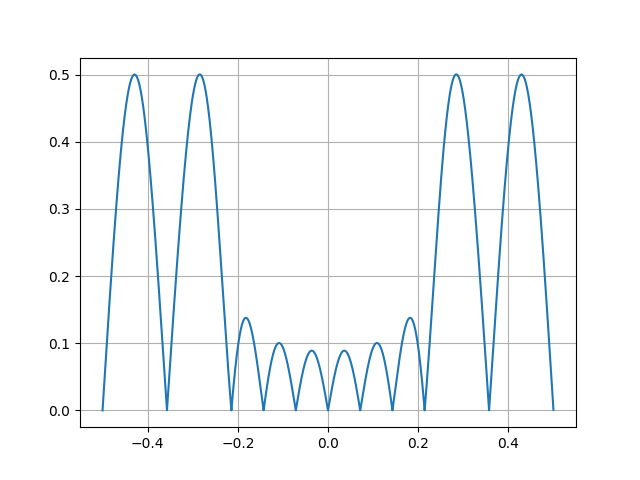

In [27]:
plt.close()
dots = 2**14
yf = np.abs(np.fft.fftshift(np.fft.fft(y, dots))) / len(x)
ff = np.fft.fftshift(np.fft.fftfreq(dots))
plt.plot(ff, yf)
plt.grid()

# Модуль 3. Частотная ось ДПФ.

## Задача 3.1. Спектр отрезка синусоиды.

| Первая буква: | А,Б | В,Г | Д,Е,Ё | Ж,З,И,Й,К | Л,М | Н,О | П,Р | С,Т,У,Ф | Х,Ц,Ч,Ш,Щ,Ы | Э,Ю,Я |
|:-----------:|:---:|:---:|:---:|:---:|:---:|:--:|:---:|:---:|:---:|:--:|
|  $f_0$**, кГц** |  120  |  20  |  30  |  40  |  50  |  60 |  70  |  80  |  90 | 110 |

Подать на вход цифрового осциллографа с генератора синусоидальный сигнал с частотой $f_0$ и амплитудой 2 В. Установить следующие настройки управляющей программы осциллографа:

* закрытый вход,
* автоматическая синхронизация по восходящему фронту входного сигнала, 
* пробник 1:1,
* число выборок 1000.
* Время/дел. выбрать таким, чтобы частота дискретизации (Fsmpl в информации о выборках) была больше $4 f_0$.

1) Построить график спектра дискретизованного сигнала с помощью ДПФ достаточно большой размерности (например, 2**18). 
2) Сравнить график спектра с теоретическим. Объяснить отличия. 
3) Определить частоту синусоиды по спектру. 
4) Оценить уровень первого бокового лепестка относительно главного в дБ в спектре. 
4) Проанализировать, наблюдается ли эффект наложения при дискретизации в данном случае. 


In [28]:
f0 = 50_000
dt = 1/(4*f0)
print(dt*1e6, "us")
"2us sampling"

5.0 us


'2us sampling'

In [29]:
file_name = "Data/vian/sin.txt"
# Считывание сигнала
fs, x = osc_read_txt(file=file_name)
#x=x-np.mean(x)
x=x[0:100]

# Вычисление ДПФ и ДВПФ
dtft_points=2**18
X_dtft = np.fft.fftshift(np.fft.fft(x, dtft_points))
f_dtft = np.fft.fftshift(np.fft.fftfreq(X_dtft.shape[0], d=1.0/fs))

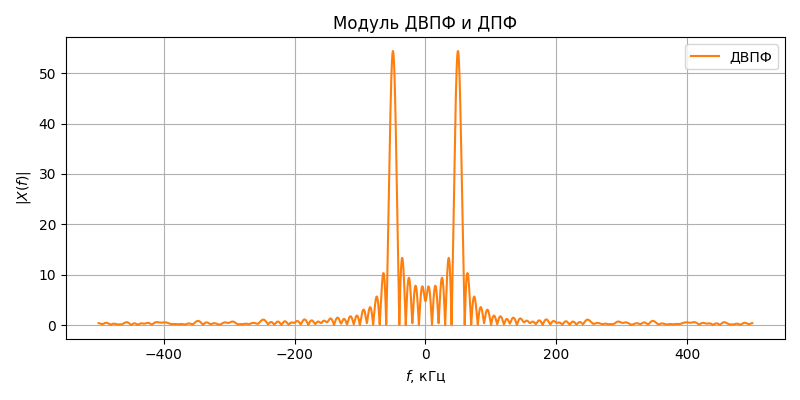

In [30]:
# Пример с построением графиков для модуля ДВПФ и ДПФ.
plt.figure(figsize=[8, 4])
k = np.arange(len(x))
plt.plot(f_dtft/1e3, abs(X_dtft), 'C1', label="ДВПФ")
plt.grid()
plt.title("Модуль ДВПФ и ДПФ")
plt.xlabel("$f$, кГц")
plt.ylabel("$|X(f)|$")
plt.legend()
plt.tight_layout()
plt.show()
#plt.close()

## Задача 3.2. Анализ звукового файла.

Записать несколько секунд монотонного звука в wav файл (например, звучание одной ноты музыкального инструмента). Для записи можно использовать, например, встроенный или внешний микрофон ноутбука или мобильного устройства. 

Для аудиозаписи:
* указать шаг и частоту дискретизации; 
* выбрать некоторый интервал отсчетов в информативной области сигнала и для него осуществить ДПФ-анализ, объяснить выбор этой области;
* определить с помощью ДПФ-анализа частоту основого колебания.

In [31]:
file_name = 'Data/vian/trimmedAudio.wav'
fs, x=scipy.io.wavfile.read(file_name)
x, x.shape

(array([[-71, -54],
        [-66, -52],
        [-62, -49],
        ...,
        [  9,  -6],
        [  9,  -9],
        [  9, -11]], dtype=int16),
 (60480, 2))

In [32]:
timelen = 2.31-1.05  # len in sec of file i put here
dt = timelen / len(x)  # dt in sec
fs = 1/dt  # discetisation freq in Hz
print(f'discretization freq is {fs} Hz')

discretization freq is 48000.0 Hz


In [33]:
plt.plot(x[:, 0])

In [34]:
plt.plot(x[:, 1])
plt.close()

[ -236 -1289 -1207  -723   865   200  -696 -1479  -662 -1010   704  1899
  -704  -899  -492   293   457  1742   546 -1161   -43   106  1455   785
   294    10  -135   306   986   824 -1985  -786  -193  -364   287  -191
 -1541 -2308   351   403   640  -121 -1384  -855  -310  1897  1856   566
 -1177    90   795   521  2005   314  -827  -523  1169   458   112   298
 -1330  -207   165   662  -708 -1873 -1273  -125   680  -238   247 -1856
 -1637   870  1576   880   -83  -281 -1657  1044  2396  1515   478  -860
    99   510  1379   599    53 -1351  -804  1403  -117  -567 -1045 -1164
 -1096   882   524 -1887 -1201 -1391   432  1300  1082   -69 -1268  -659
   860  2750   738   344  -274 -1041   940  2305  1249 -1036  -184  -809
   125  1122  -246  -974 -1827  -368   421   468 -1208 -1379  -937  -836
  1718   842 -1029 -1537    98   792  1777  2203  -686  -927  -460  1381
  1973   945  -182 -1070  -351   260  2050   256 -1382  -791  -579  -159
   184    62 -2297 -1176   198   395   450  -914 -1

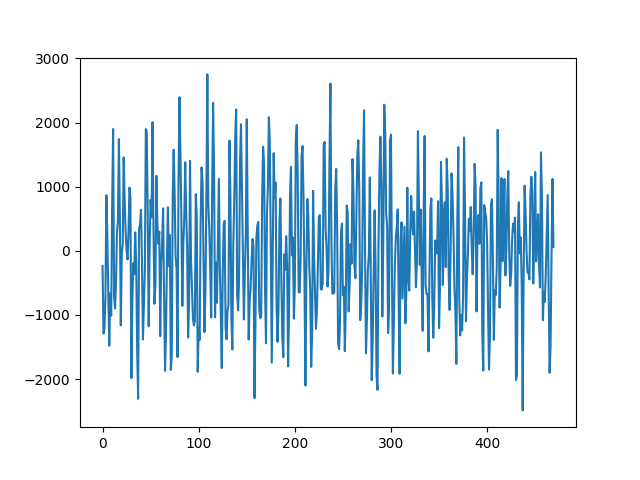

In [35]:
plt.close()
# y = x[int(1.81e4):int(2.2e4), 1]
y = x[int(1.81e4+30):int(1.81e4+500), 1]
print(y, y.shape)
print("it's the most consistent part")
plt.plot(y)

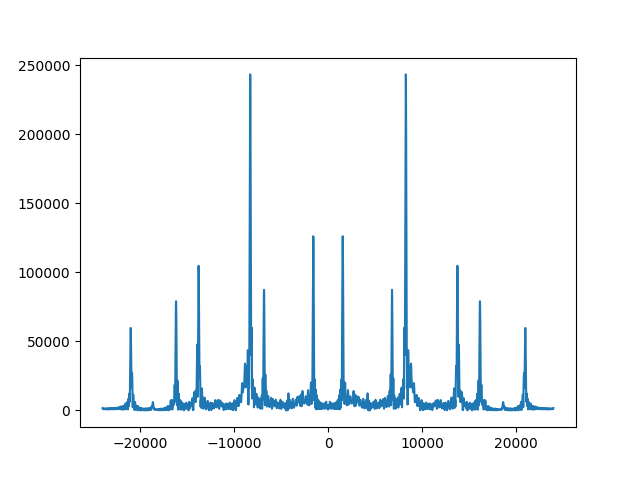

In [36]:
plt.close()
xf = np.abs(np.fft.fftshift(np.fft.fft(y, 2**24)))

freqs = np.fft.fftshift(np.fft.fftfreq(xf.shape[0], d=1.0/fs))

plt.plot(freqs, xf)
# plt.plot(xf)

In [37]:
# print(f'max amplitude is at 4208, 1558, {abs(freqs[np.argmax(xf)]):.2f} (G# octave 8) Hz')
print(f'max amplitude is at 1567 (G octave 3), {abs(freqs[np.argmax(xf)]):.2f} (C octave 8) Hz')

max amplitude is at 1567 (G octave 3), 8283.59 (C octave 8) Hz


**Приложение.** Ниже приведена таблица соответствия нот и частот.

| Нота | Название                    | Частота (Гц) |
|------|-----------------------------|--------------|
|E |Ми пятой октавы |5274.00|
|D# |Ре-диез пятой октавы |4978.00|
|D |Ре пятой октавы |4698.40|
|C# |До-диез пятой октавы |4434.80|
|C |До пятой октавы |4186.00|
|B |Си четвёртой октавы |3951.00|
|A# |Ля-диез четвёртой октавы |3729.20|
|A |Ля четвёртой октавы |3440.00|
|G# |Соль-диез четвёртой октавы |3332.40|
|G |Соль четвёртой октавы |3136.00|
|F# |Фа-диез четвёртой октавы |2960.00|
|F |Фа четвёртой октавы |2793.80|
|E |Ми четвёртой октавы |2637.00|
|D# |Ре-диез четвёртой октавы |2489.00|
|D |Ре четвёртой октавы |2349.20|
|C# |До-диез четвёртой октавы |2217.40|
|C |До четвёртой октавы |2093.00|
|B |Си третьей октавы |1975.50|
|A# |Ля-диез третьей октавы |1864.60|
|A |Ля третьей октавы |1720.00|
|G# |Соль-диез третьей октавы |1661.20|
|G |Соль третьей октавы |1568.00|
|F# |Фа-диез третьей октавы |1480.00|
|F |Фа третьей октавы |1396.90|
|E |Ми третьей октавы |1318.50|
|D# |Ре-диез третьей октавы |1244.50|
|D |Ре третьей октавы |1174.60|
|C# |До-диез третьей октавы |1108.70|
|C |До третьей октавы |1046.50|
|B |Си второй октавы |987.75|
|A# |Ля-диез второй октавы |932.32|
|A |Ля второй октавы |880.00|
|G# |Соль-диез второй октавы |830.60|
|G |Соль второй октавы |784.00|
|F# |Фа-диез второй октавы |739.98|
|F |Фа второй октавы |698.46|
|E |Ми второй октавы |659.26|
|D# |Ре-диез второй октавы |622.26|
|D |Ре второй октавы |587.32|
|C# |До-диез второй октавы |554.36|
|C |До второй октавы |523.25|
|B |Си первой октавы |493.88|
|A# |Ля-диез первой октавы |466.16|
|A |Ля первой октавы |440.00|
|G# |Соль-диез первой октавы |415.30|
|G |Соль первой октавы |392.00|
|F# |Фа-диез первой октавы |369.99|
|F |Фа первой октавы |349.23|
|E |Ми первой октавы |329.63|
|D# |Ре-диез первой октавы |311.13|
|D |Ре первой октавы |293.66|
|C# |До-диез первой октавы |277.18|
|C |До первой октавы |261.63|
|B |Си малой октавы |246.96|
|A# |Ля-диез малой октавы |233.08|
|A |Ля малой октавы |220.00|
|G# |Соль-диез малой октавы |207.00|
|G |Соль малой октавы |196.00|
|F# |Фа-диез малой октавы |185.00|
|F |Фа малой октавы |174.62|
|E |Ми малой октавы |164.81|
|D# |Ре-диез малой октавы |155.56|
|D |Ре малой октавы |147.83|
|C# |До-диез малой октавы |138.59|
|C |До малой октавы |130.82|
|B |Си большой октавы |123.48|
|A# |Ля-диез большой октавы |116.54|
|A |Ля большой октавы |110.00|
|G# |Соль-диез большой октавы |103.80|
|G |Соль большой октавы |98.00|
|F# |Фа-диез большой октавы |92.50|
|F |Фа большой октавы |87.31|
|E |Ми большой октавы |82.41|
|D# |Ре-диез большой октавы |77.78|
|D |Ре большой октавы |73.91|
|C# |До-диез большой октавы |69.30|
|C |До большой октавы |65.41|
|B |Си контроктавы |61.74|
|A# |Ля-диез контроктавы |58.26|
|A |Ля контроктавы |55.00|
|G# |Соль-диез контроктавы |51.90|
|G |Соль контроктавы |49.00|
|F# |Фа-диез контроктавы |46.25|
|F |Фа контроктавы |43.65|
|E |Ми контроктавы |41.21|
|D# |Ре-диез контроктавы |38.88|
|D |Ре контроктавы |36.95|
|C# |До-диез контроктавы |34.65|
|C |До контроктавы |32.70|
|B |Си субконтроктавы |30.87|
|A# |Ля-диез субконтроктавы |29.13|
|A |Ля субконтроктавы |27.50|
|G# |Соль-диез субконтроктавы |25.95|
|G |Соль субконтроктавы |24.50|
|F# |Фа-диез субконтроктавы |23.12|
|F |Фа субконтроктавы |21.82|
|E |Ми субконтроктавы |20.61|